# Data Handling and Analysis

This tutorial gives an in depth overview of the ``PhotometryData`` class. ``PhotometryData`` is the main container for trial-wise photometry signals after an experiment has been processed and split into windows.

``PhotometryData`` is built around an [AnnData](https://anndata.readthedocs.io/) object. You do not need to know the ins and outs of AnnData to use this package, but it helps to understand the layout:

* ``X`` (np.ndarray): contains the main signal matrix with shape ``(n_trials, n_timepoints)``.

* ``obs`` (pd.DataFrame): contains a table of metadata with shape ``(n_trials, n_observations)``.

* ``var`` (pd.DataFrame): contains one row of metadata for each timepoint. In this package, its main use is to hold the values of the timepoint in the column ``t``.

* ``layers`` (np.ndarray): can store extra signal matrices of the same shape of ``X``, such as standard deviations after averaging.

* ``uns`` (dict): stores unstructured metadata about the dataset, subject, processing choices, and file provenance.

# Setup

First we need to import the packages used in this tutorial.

In [1]:
import numpy as np
import pandas as pd
from plotnine import * # type: ignore

from PhoPro import PhotometryData

# 1. Loading Trial-wise Data

Most workflows create ``PhotometryData`` by calling ``PhotometryExperiment.extract_trial_data()`` after preprocessing an experiment. The result can then be savedas an ``.h5ad`` file. The ``zarr`` format is also supported, but the ``.h5ad`` is more straight-forward.

In [2]:
data = PhotometryData.read_h5ad('data/trials/example_trials.h5ad')
data

Photometry dataset with 20 trials, 1598 timepoints, and 5 observations.

The string representation gives a compact summary of how many trials, timepoints, and observation columns are available.

The underlying trial matrix is available through ``.X``, where rows are trials and columns are timepoints.

In [3]:
data.X.shape

(20, 1598)

The time axis is available through ``.ts``. ``PhotometryData`` also estimates ``.freq`` and ``.dt`` from this time axis.

In [4]:
print(data.ts[:5])
print(data.ts[-5:])
print(data.freq)
print(data.dt)

[-8.        -7.9899901 -7.9799802 -7.9699703 -7.9599604]
[7.9457707 7.9557806 7.9657905 7.9758004 7.9858103]
94.07852623904556
0.010629418210262826


# 2. Understanding ``obs``, ``var``, ``uns``, and ``layers``

The ``obs`` dataframe is where trial-level metadata lives. In this example, each row is a trial and the columns contain event times relative to the window. A value of ``NaN`` in an event column represents that the event does not within that trial.

In [5]:
data.obs.head()

,trial_num,trial_cue,lever1,lever2,shock
0,1,-3.52,0.0,NaN,NaN
1,2,-2.71,0.0,NaN,1.22
2,3,0.00,NaN,NaN,NaN
3,4,-3.94,0.0,NaN,NaN
4,5,-3.79,0.0,NaN,NaN


The ``var`` dataframe is across the timepoint axis. With the ``t`` containing the value of the time points.

In [6]:
data.var.head()

,t
0,-8.00000
1,-7.98999
2,-7.97998
3,-7.96997
4,-7.95996


The ``uns`` dictionary stores metadata that applies to the whole dataset. If the trial data came from ``PhotometryExperiment.extract_trial_data()``, ``uns`` is automatically populated with the experiment's ``metadata``.

In [7]:
data.uns

{'age': 'young',
 'correction_method': 'dF/F',
 'invalid_windows': None,
 'reference_fit': {'coeffs': array([-0.00458822,  1.24991004]),
  'r2_val': 0.9990778344806817,
  'type': 'isosbestic'},
 'sex': 'male',
 'source': 'data/experiments/example_experiment.csv',
 'subject': 'animal_1'}

Layers store additional matrices with the same shape as ``X``. This example starts without extra layers, but later we will create layers by collapsing trials. Layers can be easily accessed with the ``get_layers`` method.

In [8]:
list(data.adata.layers.keys())

[]

# 3. Constructing ``PhotometryData`` From Arrays

``PhotometryData`` objects can also be built directly from arrays. This is useful when importing data from another package, writing tests, or creating small examples.

In [9]:
rng = np.random.default_rng(1)
time_points = np.linspace(-2, 4, 301)

obs = pd.DataFrame({
    'trial_num': np.arange(1, 7),
    'condition': ['A', 'A', 'A', 'B', 'B', 'B'],
    'cue': np.zeros(6),
})

signal = rng.normal(0, 0.05, size=(6, time_points.size))
signal += np.exp(-0.5 * ((time_points - 1.0) / 0.25) ** 2)
signal[obs['condition'].eq('B')] *= 1.4

synthetic = PhotometryData.from_arrays(
    obs=obs,
    data=signal,
    time_points=time_points,
    metadata={'source': 'synthetic example'},
)

synthetic

Photometry dataset with 6 trials, 301 timepoints, and 3 observations.

# 4. Filtering and Adding Metadata

``filter_rows`` subsets trials and returns a new object by default. With ``inplace=True``, the object will be modified in place and ``None`` will be returned. Often you will construct a trial selection from the values in ``obs``.

In [10]:
lever_trials = data.filter_rows(data.obs['lever1'].notna())
lever_trials

Photometry dataset with 9 trials, 1598 timepoints, and 5 observations.

``mutate_obs`` creates a copy and adds or replaces observation columns. Values can be arrays, scalars, or functions that receive the copied ``PhotometryData`` object.

In [11]:
annotated = data.mutate_obs(
    has_lever = lambda d: d.obs['lever1'].notna(),
    has_shock = lambda d: d.obs['shock'].notna(),
    trial_epoch = lambda d: np.where(d.obs['trial_num'] <= 10, 'early', 'late'),
)

annotated.obs.head()

,trial_num,trial_cue,lever1,lever2,shock,has_lever,has_shock,trial_epoch
0,1,-3.52,0.0,NaN,NaN,True,False,early
1,2,-2.71,0.0,NaN,1.22,True,True,early
2,3,0.00,NaN,NaN,NaN,False,False,early
3,4,-3.94,0.0,NaN,NaN,True,False,early
4,5,-3.79,0.0,NaN,NaN,True,False,early


You can modify the ``obs`` table directly, or use ``add_obs_columns`` and ``add_metadata`` to modify the object directly. The latter are useful for adding information from dictionaries, such as annotation files.

In [12]:
with_extra = data.copy()

with_extra.obs['subject'] = 'animal_1'
with_extra.obs.head()

,trial_num,trial_cue,lever1,lever2,shock,subject
0,1,-3.52,0.0,NaN,NaN,animal_1
1,2,-2.71,0.0,NaN,1.22,animal_1
2,3,0.00,NaN,NaN,NaN,animal_1
3,4,-3.94,0.0,NaN,NaN,animal_1
4,5,-3.79,0.0,NaN,NaN,animal_1


In [13]:
with_extra.add_obs_columns({
    'session': 'example_session',
    'cohort': 'tutorial',
})

with_extra.add_metadata({
    'tutorial_note': 'added during Handling Data tutorial',
})

with_extra.obs[['session', 'cohort']].head()

,session,cohort
0,example_session,tutorial
1,example_session,tutorial
2,example_session,tutorial
3,example_session,tutorial
4,example_session,tutorial


Columns can be removed with ``drop_obs_columns``.

In [14]:
with_extra.drop_obs_columns(['tutorial_note', 'cohort'])
with_extra.obs.head()

,trial_num,trial_cue,lever1,lever2,shock,subject,session
0,1,-3.52,0.0,NaN,NaN,animal_1,example_session
1,2,-2.71,0.0,NaN,1.22,animal_1,example_session
2,3,0.00,NaN,NaN,NaN,animal_1,example_session
3,4,-3.94,0.0,NaN,NaN,animal_1,example_session
4,5,-3.79,0.0,NaN,NaN,animal_1,example_session


# 5. Plotting Trials

``plot_trials`` converts trial data to a long dataframe and passes it to the ``utils.graphing`` helper module. It returns a ``ggplot`` object, so you can add plotnine layers, labels, and themes.

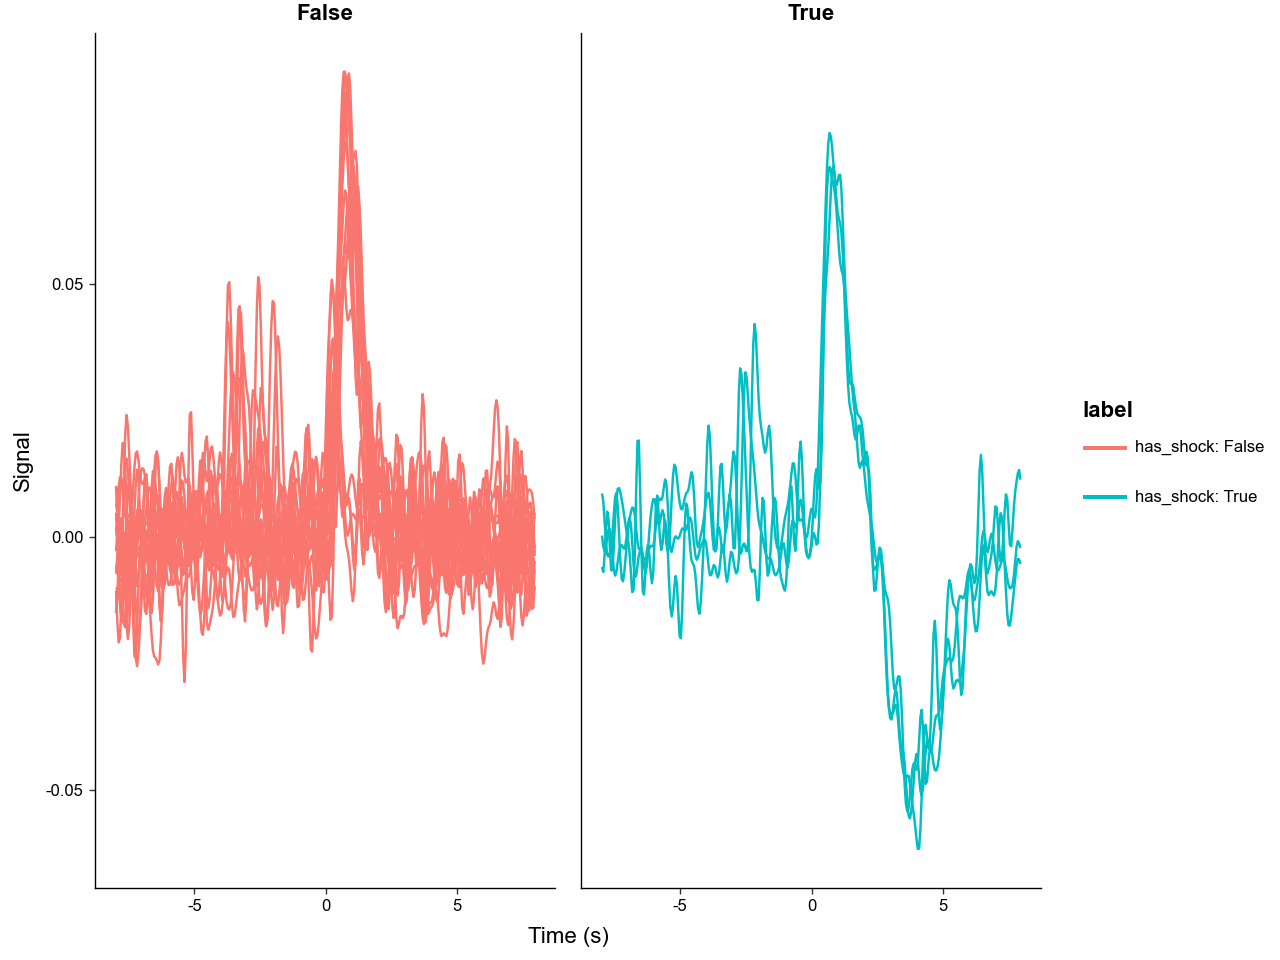

In [15]:
annotated.plot_trials(
    label_with='has_shock',
    group_on='has_shock',
    downsample=5,
)

Use ``sel`` to plot a subset of trials. ``label_with`` controls legend labels and ``group_on`` controls line grouping.

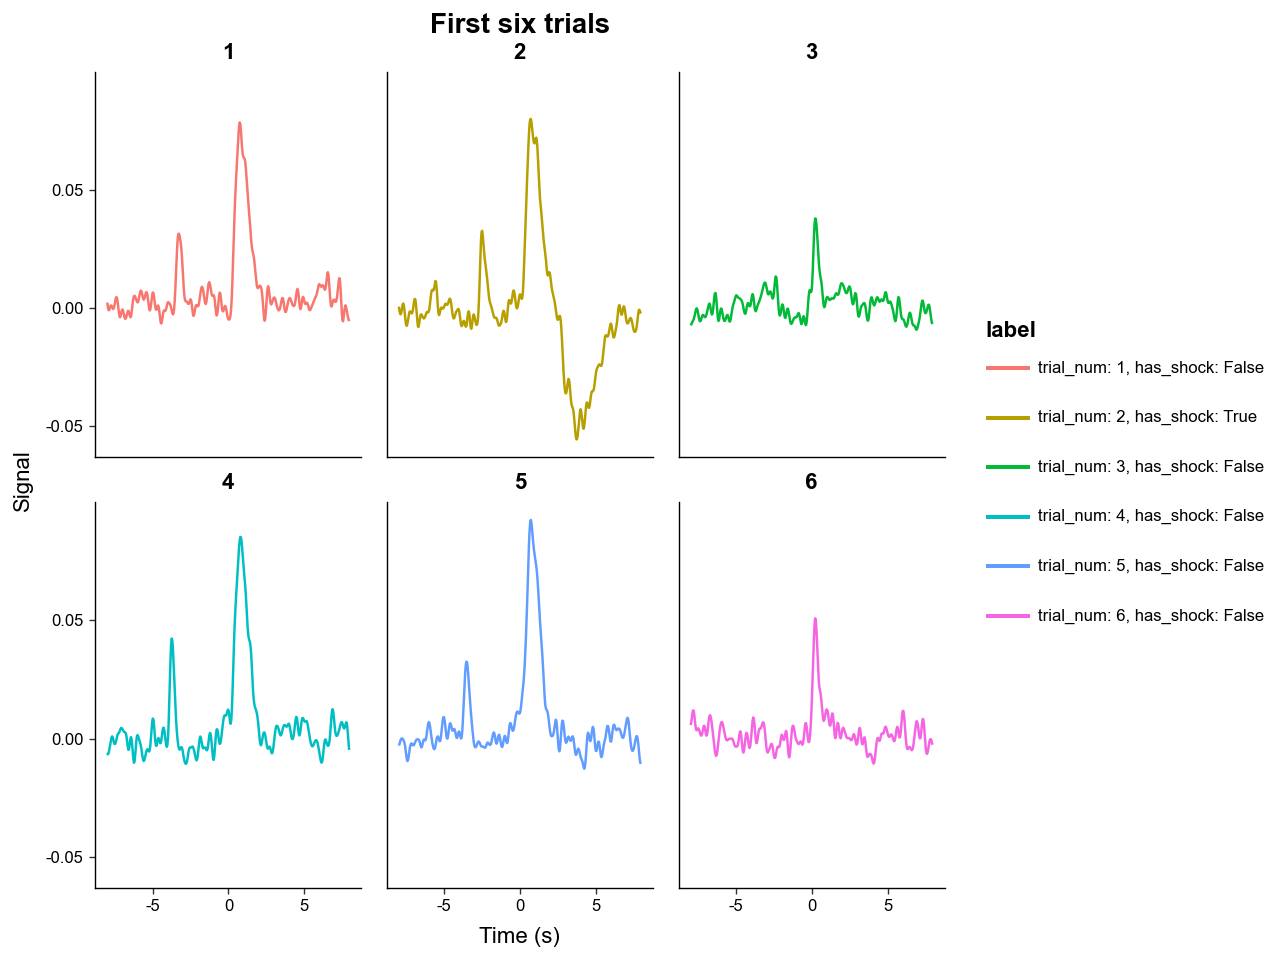

In [17]:
p = annotated.plot_trials(
    sel=np.arange(6),
    label_with=['trial_num', 'has_shock'],
    group_on='trial_num',
    downsample=4,
)

p + labs(title='First six trials')

# 6. Downsampling

Downsampling is helpful for plotting, exporting, and reducing memory use. ``downsample`` returns a new ``PhotometryData`` object with fewer timepoints.

In [18]:
small = data.downsample(factor=10)

print(data.X.shape)
print(small.X.shape)
print(small.ts[:5])

(20, 1598)
(20, 159)
[-7.95495545 -7.85485645 -7.75475745 -7.65465845 -7.55455945]


Two methods are supported. ``method='mean'`` downsamples using mean pooling while ``method='resample'`` uses ``scipy.signal.resample_ploy`` to downsample and accepts options such as ``window`` and ``padtype``. ``'resample'`` is generally more rigorious, but ``'mean'`` is simpler and faster.

In [20]:
resampled = data.downsample(
    factor=8,
    method='resample',
    window=('kaiser', 5),
)

resampled

Photometry dataset with 20 trials, 200 timepoints, and 5 observations.

# 7. Averaging Trials

``collapse`` summarizes trials by group. The primary aggregation (mean by default) becomes the new ``X`` matrix, and any additional metrics become layers. Passed ``data_cols`` undergo the same aggregation (including additional metrics) and are passed down to the new object.

In [46]:
collapsed = annotated.collapse(
    group_on='has_shock',
    method=np.nanmean,
    metrics={'std': np.nanstd, 'sem': lambda x, axis: np.nanstd(x, axis=axis) / np.sqrt(x.shape[axis])},
    data_cols=['trial_cue'],
    count_col='n',
)

collapsed.obs

,has_shock,n,trial_cue,trial_cue_std,trial_cue_sem
0,False,17,-2.254706,1.541745,0.373928
1,True,3,-2.680000,0.225536,0.130213


The collapsed object now has one row per aggregated group and the same time axis as the original data.

In [23]:
print(collapsed.X.shape)
print(list(collapsed.adata.layers.keys()))

(2, 1598)
['std', 'sem']


Because the extra metrics are stored as layers, they can be used as error ribbons in ``plot_trials``.

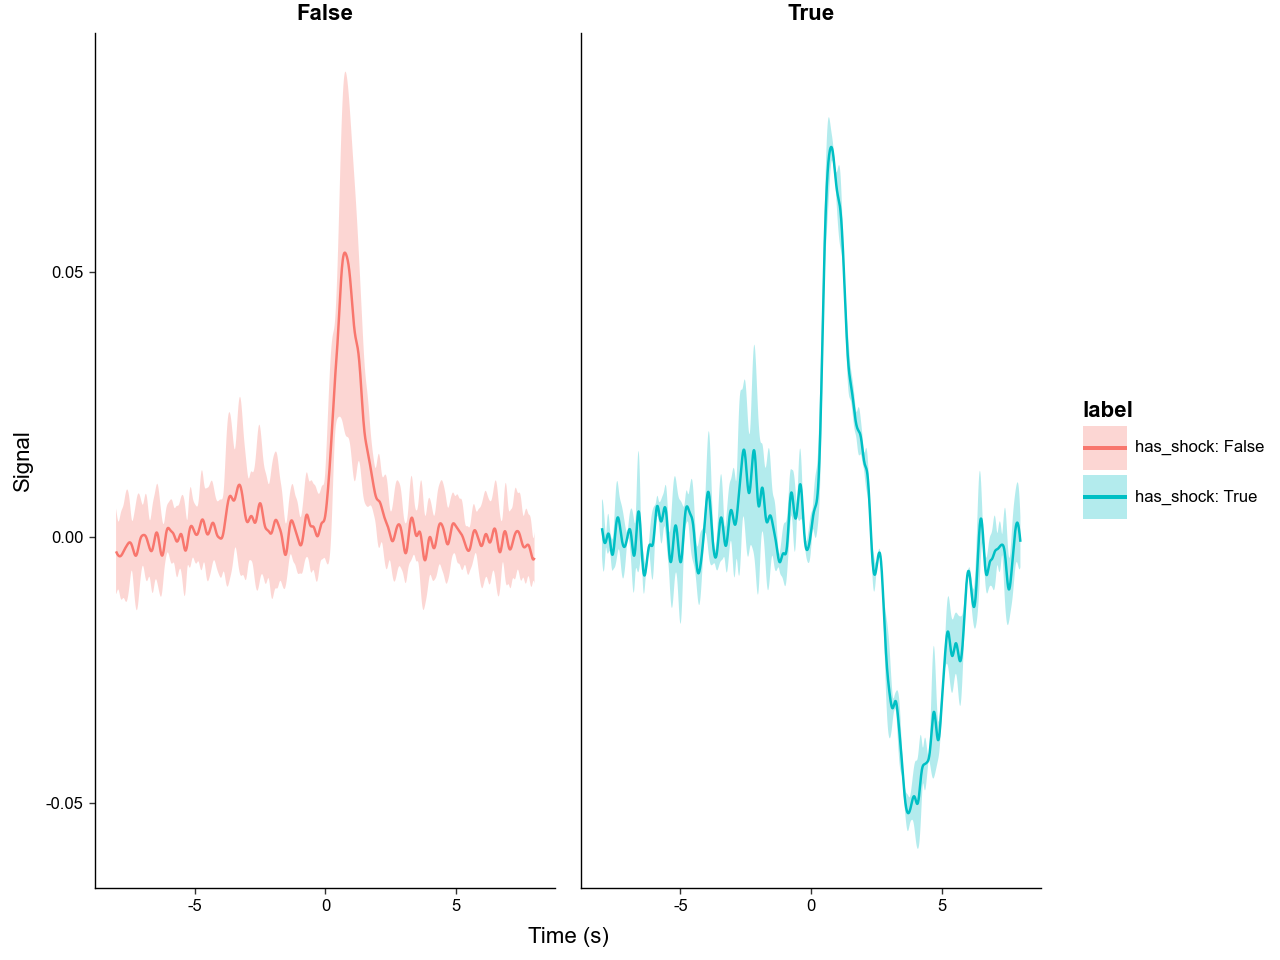

In [24]:
collapsed.plot_trials(
    label_with='has_shock',
    group_on='has_shock',
    err_layer='std',
)

If ``group_on=None`` (default), all trials are collapsed into one average trace.

In [26]:
grand_average = data.collapse(group_on=None, metrics={'std': np.nanstd})
grand_average

Photometry dataset with 1 trials, 1598 timepoints, and 1 observations.

# 8. Re-windowing Around Events

``window`` creates a new ``PhotometryData`` object by slicing or interpolating each trial around a center time. Centers can be a scalar, an array, or the name of an ``obs`` column.

A scalar center is broadcast to all trials. This example keeps the interval from 1 second before time 0 to 3 seconds after time 0.

In [29]:
post_cue = data.window(
    centers=0.0,
    bounds=(-1, 3),
)

print(post_cue.X.shape)
print(post_cue.ts[:5])
print(post_cue.ts[-5:])

(20, 376)
[-0.99916531 -0.98853589 -0.97790648 -0.96727706 -0.95664764]
[2.94434884 2.95497826 2.96560768 2.9762371  2.98686652]


When ``event_cols`` are provided, those event times are re-centered relative to each window center. For example, after centering on ``shock``, the shock column is zero for trials that contain shocks.

In [30]:
shock_trials = data.filter_rows(data.obs['shock'].notna())

shock_centered = shock_trials.window(
    centers='shock',
    bounds=(-2, 4),
    event_cols=['trial_cue', 'lever1', 'lever2', 'shock'],
)

shock_centered.obs[['trial_num', 'trial_cue', 'lever1', 'lever2', 'shock']].head()

,trial_num,trial_cue,lever1,lever2,shock
0,2,-3.933891,-1.221208,NaN,0.0
1,8,-3.573534,-1.181168,NaN,0.0
2,20,-4.404356,-1.461445,NaN,0.0


The default ``strategy='nearest'`` rounds windows to sampled timepoints. Use ``strategy='interp'`` to interpolate every trial onto an exact centered time grid.

In [78]:
nearest_window = shock_trials.window(
    centers='shock',
    bounds=(-1, 2),
    strategy='nearest',
)

interp_window = shock_trials.window(
    centers='shock',
    bounds=(-1, 2),
    strategy='interp',
)

print(nearest_window.ts[:5])
print(interp_window.ts[:5])

[-0.99916531 -0.98853589 -0.97790648 -0.96727706 -0.95664764]
[-1.         -0.98937058 -0.97874116 -0.96811175 -0.95748233]


If you have windows that extend outside the available time range, they will be default raise an error (``invalid_window_policy='error'``). Set ``invalid_window_policy='drop'`` to remove those trials instead.

In [31]:
valid_only = data.window(
    centers='shock',
    bounds=(-4, 4),
    event_cols=['shock'],
    invalid_window_policy='drop',
    verbose=True,
)

valid_only

Photometry dataset with 20 trials, 753 timepoints, and 5 observations.

# 9. Signal Features

``PhotometryData`` includes a few analysis function for analyzing signals. ``difference`` calculates discrete differences along the time axis.

In [33]:
first_difference = data.difference(n=1)
second_difference = data.difference(n=2)

print(first_difference.shape)
print(second_difference.shape)

(20, 1598)
(20, 1598)


``area_under_curve`` integrates each trial over time. By default it uses the whole trace. But, you can also pass the same arguements as the ``window`` function to integrate over a specified window. A transformation can also be passed when you want a specific feature, such as positive area only.

In [35]:
full_auc = data.area_under_curve()

response_auc = data.area_under_curve(
    centers=0.0,
    bounds=(0, 3),
    transformation=lambda x: np.maximum(x, 0),
)

print(full_auc[:5])
print(response_auc[:5])

[ 0.12073882 -0.02983236  0.02391584  0.09828795  0.1060965 ]
[0.0851429  0.09229777 0.02921103 0.09070887 0.09992221]


These per-trial values are best held in ``obs`` for trial-alignment, statistical analysis, and plotting.

In [37]:
features = annotated.mutate_obs(
    response_auc=response_auc,
    peak_value=lambda d: np.nanmax(d.X[:, (d.ts >= 0) & (d.ts <= 3)], axis=1),
)

features.obs.head()

,trial_num,trial_cue,lever1,lever2,shock,has_lever,has_shock,trial_epoch,response_auc,peak_value
0,1,-3.52,0.0,NaN,NaN,True,False,early,0.085143,0.078496
1,2,-2.71,0.0,NaN,1.22,True,True,early,0.092298,0.080037
2,3,0.00,NaN,NaN,NaN,False,False,early,0.029211,0.038073
3,4,-3.94,0.0,NaN,NaN,True,False,early,0.090709,0.085493
4,5,-3.79,0.0,NaN,NaN,True,False,early,0.099922,0.092526


# 10. Peak Detection

For event-like signals, ``PhotometryData`` can detect peaks using static or rolling thresholds (with more peak detection methods in the works). The static detector estimates one threshold per trial, while the rolling detector estimates a threshold that changes over time. All peak detection methods return a ``PeakResult`` object with an underlying pandas DataFrame ``df``.

In [38]:
static_peaks = data.detect_peaks_static_threshold(
    center_method='median',
    scale_method='mad',
    test_magnitude=3,
    min_distance_sec=0.25,
    direction='positive',
)

static_peaks

    trial_idx direction  start_idx  stop_idx  start_time  stop_time  \
0           0  positive        457       496   -3.425476  -3.035090   
1           0  positive        829       971    0.298207   1.719613   
2           1  positive        538       565   -2.614674  -2.344406   
3           1  positive        828       968    0.288197   1.689583   
4           2  positive        808       845    0.087999   0.458365   
5           3  positive        413       444   -3.865911  -3.555604   
6           3  positive        828       959    0.288197   1.599494   
7           4  positive        429       468   -3.705753  -3.315367   
8           4  positive        811       961    0.118029   1.619514   
9           5  positive        800       862    0.007920   0.628534   
10          6  positive        459       482   -3.405456  -3.175228   
11          6  positive        834       927    0.348257   1.279177   
12          7  positive        579       586   -2.204268  -2.134199   
13    

Use a baseline window when the detection threshold should be estimated from a specific period instead of the whole trial.

In [39]:
baseline = data.window(
    centers=0.0,
    bounds=(-5, -1),
    invalid_window_policy='drop',
)

baseline_peaks = data.detect_peaks_static_threshold(
    baselines=baseline.X,
    test_magnitude=3,
    direction='positive',
)

baseline_peaks

    trial_idx direction  start_idx  stop_idx  start_time  stop_time  \
0           0  positive        456       497   -3.435486  -3.025080   
1           0  positive        829       973    0.298207   1.739633   
2           1  positive        239       247   -5.607634  -5.527555   
3           1  positive        533       585   -2.664723  -2.144209   
4           1  positive        821      1003    0.218128   2.039930   
5           2  positive        808       846    0.087999   0.468375   
6           3  positive        408       452   -3.915961  -3.475525   
7           3  positive        789       803   -0.102189   0.037950   
8           3  positive        821       986    0.218128   1.869761   
9           3  positive       1479      1490    6.804642   6.914751   
10          4  positive        427       472   -3.725773  -3.275327   
11          4  positive        805       966    0.057970   1.669563   
12          5  positive        799       865   -0.002090   0.658563   
13    

The rolling detector is useful when the noise level changes over the trial. However, it only performs well when your window width is substantially larger than the duration of the expected transients.

In [40]:
rolling_peaks = data.detect_peaks_rolling_threshold(
    window_width_sec=2.0,
    center_method='median',
    scale_method='mad',
    test_magnitude=3,
    min_distance_sec=0.25,
    direction='positive',
)

rolling_peaks

    trial_idx direction  start_idx  stop_idx  start_time  stop_time  \
0           0  positive        457       497   -3.425476  -3.025080   
1           1  positive        538       567   -2.614674  -2.324387   
2           2  positive        158       169   -6.418436  -6.308327   
3           2  positive        827       840    0.278187   0.408316   
4           3  positive        411       444   -3.885931  -3.555604   
5           4  positive        193       204   -6.068089  -5.957980   
6           4  positive        431       464   -3.685733  -3.355406   
7           5  positive        820       833    0.208118   0.338247   
8           6  positive        460       478   -3.395446  -3.215268   
9           8  positive        184       201   -6.158178  -5.988010   
10          9  positive        607       626   -1.923991  -1.733803   
11         10  positive        594       605   -2.054119  -1.944011   
12         12  positive        327       330   -4.726763  -4.696733   
13    

# 11. Statistical Helpers

The ANOVA methods are thin wrappers around [pingouin](https://pingouin-stats.org/). They use columns in ``obs`` as inputs, so the usual pattern is to compute trial-level features first and then run statistics on those feature columns.

In [41]:
stats_data = features.mutate_obs(
    condition=lambda d: np.where(d.obs['has_shock'], 'shock', 'no_shock'),
)

stats_data.ANOVA(
    dependent_var='response_auc',
    between='condition',
)

,Source,SS,DF,MS,F,p_unc,np2
0,condition,0.000890,1,0.000890,1.203699,0.287045,0.062681
1,Within,0.013304,18,0.000739,NaN,NaN,NaN


For repeated-measures and mixed-design ANOVA, ``obs`` needs subject and within-subject factor columns. The example below creates a small demonstration dataset by assigning tutorial factors and a tutorial-specific response column.

In [42]:
stats_demo = stats_data.mutate_obs(
    subject=lambda d: 'subject_' + ((d.obs['trial_num'] - 1) % 10 + 1).astype(str),
    period=lambda d: np.where(d.obs['trial_num'] <= 10, 'early', 'late'),
    treatment=lambda d: np.where(((d.obs['trial_num'] - 1) % 10 + 1) <= 5, 'control', 'treatment'),
    demo_response=lambda d: (
        d.obs['response_auc']
        + np.where(d.obs['trial_num'] > 10, 0.05, 0.0)
        + np.where(((d.obs['trial_num'] - 1) % 10 + 1) <= 5, 0.0, 0.03)
    ),
)

stats_demo.ANOVA_rm(
    dependent_var='demo_response',
    within='period',
    subject='subject',
)

,Source,SS,DF,MS,F,p_unc,ng2,eps
0,period,0.010878,1,0.010878,9.251173,0.013982,0.386566,1.0
1,Error,0.010583,9,0.001176,NaN,NaN,NaN,NaN


``ANOVA_mixed`` is available for one between-subject factor and one within-subject factor.

In [43]:
stats_demo.ANOVA_mixed(
    dependent_var='demo_response',
    between='treatment',
    within='period',
    subject='subject',
)

,Source,SS,DF1,DF2,MS,F,p_unc,np2,eps
0,treatment,0.003230,1,8,0.003230,7.490630,0.025571,0.483559,NaN
1,period,0.010878,1,8,0.010878,8.815984,0.017894,0.524262,1.0
2,Interaction,0.000712,1,8,0.000712,0.576626,0.469420,0.067232,NaN


# 12. Exporting to DataFrames

``trials_to_long_df`` produces one row per trial and timepoint. This format is ideal for plotting and tidy data workflows.

In [90]:
long_df = annotated.trials_to_long_df(
    obs_cols=['trial_num', 'has_shock'],
    downsample=10,
)

long_df.head()

,trial_idx,time_idx,signal,trial_num,has_shock,time
0,0,0,0.000958,1,False,-7.954955
1,0,1,-0.000714,1,False,-7.854856
2,0,2,0.000874,1,False,-7.754757
3,0,3,0.000226,1,False,-7.654658
4,0,4,0.000012,1,False,-7.554559


When a layer is present, you can export that layer instead of ``X``. You can also include an error layer as an additional column.

In [91]:
collapsed_long = collapsed.trials_to_long_df(
    err_layer='sem',
    obs_cols=['has_shock', 'n'],
)

collapsed_long.head()

,trial_idx,time_idx,signal,has_shock,n,time,sem
0,0,0,-0.002649,False,17,-8.00000,0.001954
1,0,1,-0.002766,False,17,-7.98999,0.001908
2,0,2,-0.002877,False,17,-7.97998,0.001854
3,0,3,-0.002982,False,17,-7.96997,0.001794
4,0,4,-0.003078,False,17,-7.95996,0.001734


``trials_to_wide_df`` produces one row per trial and one column per timepoint. This can be useful for external statistics packages or for the ``PhoPro.analysis.FMM`` helpers.

In [92]:
wide_df = annotated.trials_to_wide_df(
    obs_cols=['trial_num', 'has_shock'],
    signal_prefix='dff',
    downsample=20,
)

wide_df.head()

,trial_num,has_shock,dff.1,dff.2,dff.3,dff.4,dff.5,dff.6,dff.7,dff.8,...,dff.70,dff.71,dff.72,dff.73,dff.74,dff.75,dff.76,dff.77,dff.78,dff.79
0,1,False,0.000122,0.000550,0.001511,0.002090,-0.002785,-0.002417,-0.003028,-0.002797,...,0.008449,0.009303,0.008537,0.012981,0.004595,0.002771,0.003901,0.010544,-0.002842,-0.000103
1,2,True,-0.001540,0.000675,-0.006064,-0.002676,-0.001244,0.002081,-0.006566,-0.003232,...,-0.008474,-0.010621,-0.008778,-0.000318,-0.001788,-0.001703,-0.006076,-0.005013,-0.009409,-0.005980
2,3,False,-0.006419,-0.002769,-0.002080,-0.004799,-0.003436,-0.001712,0.000485,0.000087,...,-0.003205,-0.006146,-0.006072,-0.003308,-0.007286,-0.008591,-0.003664,0.001997,-0.001604,0.000505
3,4,False,-0.005536,-0.000126,-0.001551,0.001365,0.003954,0.003295,-0.000110,-0.002144,...,-0.003180,-0.009099,-0.002978,-0.002149,0.003198,0.010021,0.001886,0.004216,0.006138,0.005789
4,5,False,-0.001293,-0.000546,-0.006427,-0.005763,-0.002369,-0.001339,-0.000481,-0.002861,...,0.001017,0.003679,0.004279,0.004079,0.001271,0.003883,0.007437,-0.002461,-0.003207,-0.000067


# 13. Combining Datasets and Saving Results

``combine_obj`` concatenates datasets along the trial axis. This is useful after processing several sessions or subjects into separate ``PhotometryData`` objects.

In [44]:
early = data.filter_rows(data.obs['trial_num'] <= 10).mutate_obs(block='early')
late = data.filter_rows(data.obs['trial_num'] > 10).mutate_obs(block='late')

recombined = early.combine_obj(late)
recombined

Photometry dataset with 20 trials, 1598 timepoints, and 6 observations.

The class supports both ``.h5ad`` and zarr storage through ``write_h5ad``, ``read_h5ad``, ``write_zarr``, and ``read_zarr``.

In [45]:
# Write to the tutorial output directory.
recombined.write_h5ad('output/recombined_trials.h5ad')

loaded_again = PhotometryData.read_h5ad('output/recombined_trials.h5ad')
loaded_again

Photometry dataset with 20 trials, 1598 timepoints, and 6 observations.

For large workflows, ``append_on_disk_h5ad`` appends a dataset to an existing ``.h5ad`` file without keeping every dataset in memory at the same time. If the target file does not exist yet, it simply writes the current object.

In [46]:
# This is a pattern for bulk workflows. Running it repeatedly appends data.
# append_path = 'output/all_sessions.h5ad'
# early.append_on_disk_h5ad(append_path)
# late.append_on_disk_h5ad(append_path)

# 14. Method Chaining With ``pipe``

``pipe`` lets you insert custom functions into a chain of ``PhotometryData`` operations, much like the ``pipe`` function in pandas. The function receives the object as its first argument and returns a ``PhotometryData`` object. Method chaining helps keep your code readable and neat, and with ``pipe`` and ``mutate_obs`` almost all manipulations of ``PhotometryData`` are achieveble within method chains.

In [47]:
def add_response_features(obj: PhotometryData, start: float = 0, stop: float = 3) -> PhotometryData:
    return obj.mutate_obs(
        response_auc=obj.area_under_curve(centers=0.0, bounds=(start, stop)),
        response_peak=lambda d: np.nanmax(d.X[:, (d.ts >= start) & (d.ts <= stop)], axis=1),
    )

summary = (
    data
    .pipe(add_response_features, start=0, stop=3)
    .mutate_obs(has_shock=lambda d: d.obs['shock'].notna())
    .collapse(group_on='has_shock', data_cols=['response_auc', 'response_peak'])
)

summary.obs

,has_shock,n,response_auc,response_peak,response_auc_std,response_peak_std
0,False,17,0.064167,0.067970,0.028524,0.019729
1,True,3,0.081732,0.075715,0.006220,0.003059


# Summary

``PhotometryData`` is designed to keep trial-wise signals and trial metadata synchronized.

# AI Use Disclaimer

Generative AI was used to assist in the creation of this tutorial. I plan to replace it in the future with a more polished version.